[INFO] Filtered rows kept: 7,381,762
[INFO] Used primary: 7,381,762 | Used fallback: 0
[INFO] Skipped empty: 4,021,876 | Bad JSON: 0
[INFO] Topic assignments in model: 7,381,762


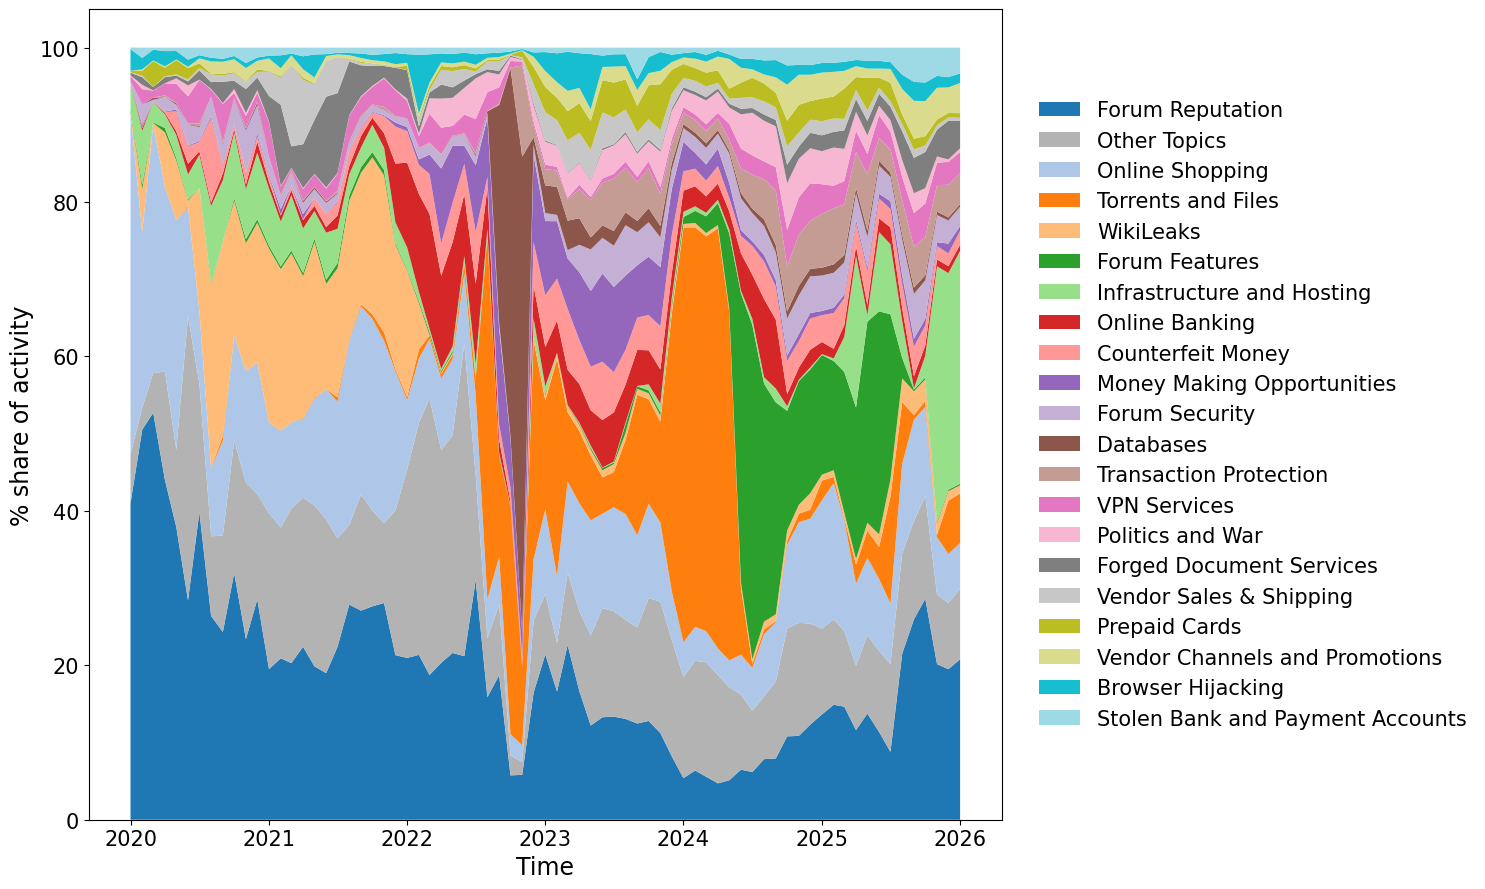

Saved figure PDF to: /home/darknet/2026-01-27_201419_domain_with_snapshots/rq1b/temporal_prevalence_stacked_area_top20.pdf
Saved figure PNG to: /home/darknet/2026-01-27_201419_domain_with_snapshots/rq1b/temporal_prevalence_stacked_area_top20.png
Saved long table to: /home/darknet/2026-01-27_201419_domain_with_snapshots/rq1b/temporal_prevalence_long_top20.csv
Saved wide table to: /home/darknet/2026-01-27_201419_domain_with_snapshots/rq1b/temporal_prevalence_wide_top20.csv
Saved top-topic summary to: /home/darknet/2026-01-27_201419_domain_with_snapshots/rq1b/temporal_prevalence_top20_topics.csv

Top 20 grouped labels included explicitly in the chart:
 1. Forum Reputation
 2. Online Shopping
 3. Torrents and Files
 4. WikiLeaks
 5. Forum Features
 6. Infrastructure and Hosting
 7. Online Banking
 8. Counterfeit Money
 9. Money Making Opportunities
10. Forum Security
11. Databases
12. Transaction Protection
13. VPN Services
14. Politics and War
15. Forged Document Services
16. Vendor Sales

,Final,Count
0,Torrents and Files,1026851
1,Forum Reputation,903883
2,Online Shopping,558270
3,Forum Features,524089
4,Infrastructure and Hosting,461151
5,Transaction Protection,243077
6,Forum Security,204509
7,Counterfeit Money,197892
8,Databases,192833
9,Online Banking,175989


,month,Final_plot,Count,% share
0,2020-01-01,Browser Hijacking,89,2.807571
1,2020-01-01,Counterfeit Money,1,0.031546
2,2020-01-01,Forged Document Services,11,0.347003
3,2020-01-01,Forum Features,7,0.220820
4,2020-01-01,Forum Reputation,1299,40.977918
5,2020-01-01,Forum Security,2,0.063091
6,2020-01-01,Infrastructure and Hosting,111,3.501577
7,2020-01-01,Money Making Opportunities,4,0.126183
8,2020-01-01,Online Shopping,1406,44.353312
9,2020-01-01,Other Topics,202,6.372240


Final_plot,Forum Reputation,Other Topics,Online Shopping,Torrents and Files,WikiLeaks,Forum Features,Infrastructure and Hosting,Online Banking,Counterfeit Money,Money Making Opportunities,...,Databases,Transaction Protection,VPN Services,Politics and War,Forged Document Services,Vendor Sales & Shipping,Prepaid Cards,Vendor Channels and Promotions,Browser Hijacking,Stolen Bank and Payment Accounts
month,,,,,,,,,,,,,,,,,,,,,
2020-01-01,40.977918,6.372240,44.353312,0.000000,0.000000,0.220820,3.501577,0.000000,0.031546,0.126183,...,0.000000,0.000000,0.662461,0.094637,0.347003,0.063091,0.189274,0.000000,2.807571,0.189274
2020-02-01,50.520183,2.829796,22.721598,0.000000,5.617978,0.582605,6.949646,0.374532,0.124844,0.291303,...,0.000000,0.000000,1.997503,0.540990,0.998752,0.208073,0.624220,0.166459,1.498127,1.331669
2020-03-01,52.708638,5.142753,32.265739,0.000000,0.109810,0.091508,2.653734,0.036603,0.036603,0.018302,...,0.256223,0.000000,0.915081,0.036603,0.439239,0.000000,3.367496,0.073206,1.390922,0.274524
2020-04-01,43.994334,14.050992,23.937677,0.000000,7.025496,0.566572,1.784703,0.198300,0.113314,0.056657,...,0.000000,0.226629,1.529745,0.028329,0.793201,0.113314,1.104816,0.169972,1.983003,0.453258
2020-05-01,37.893773,10.018315,29.725275,0.018315,7.728938,0.311355,3.003663,0.457875,2.582418,0.238095,...,0.183150,0.036630,2.490842,0.714286,0.347985,0.164835,1.849817,0.073260,1.098901,0.439560


In [1]:
import json
import csv
import pandas as pd
import matplotlib.pyplot as plt
from bertopic import BERTopic
from pathlib import Path

# -------------------------
# Fix for BERTopic loading
# -------------------------
class IdentityReducer:
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X
    def fit_transform(self, X, y=None):
        return X

# -------------------------
# PATHS
# -------------------------
JSONL_PATH = Path("preprocessed_from_disk.jsonl")
MODEL_PATH = Path("./DarkBERT/output_darkbert__900_90/bertopic_model")
LABELS_PATH = Path("./DarkBERT/original_run_darkbert_900_90/final_labeling.csv")

OUT_DIR = Path("./rq1b")
OUT_DIR.mkdir(parents=True, exist_ok=True)

FIG_PDF = OUT_DIR / "temporal_prevalence_stacked_area_top20.pdf"
FIG_PNG = OUT_DIR / "temporal_prevalence_stacked_area_top20.png"
OUT_LONG = OUT_DIR / "temporal_prevalence_long_top20.csv"
OUT_WIDE = OUT_DIR / "temporal_prevalence_wide_top20.csv"
OUT_TOPICS = OUT_DIR / "temporal_prevalence_top20_topics.csv"

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

# -------------------------
# FONT SIZES
# -------------------------
AXIS_LABEL_FONTSIZE = 17
X_TICK_FONTSIZE = 15
Y_TICK_FONTSIZE = 15  # increased by 2
LEGEND_FONTSIZE = 15

# -------------------------
# SAME FILTERING AS TRAINING
# -------------------------
DOC_FIELD_PRIMARY = "preprocessed_trafilatura"
DOC_FIELD_FALLBACK = "preprocessed_content"

def load_filtered_metadata_from_jsonl(path: Path, primary_field: str, fallback_field: str = None):
    rows = []

    bad_json = 0
    skipped_empty = 0
    used_primary = 0
    used_fallback = 0

    with path.open("r", encoding="utf-8", errors="replace") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                bad_json += 1
                continue

            text = rec.get(primary_field, "")
            if isinstance(text, str) and text.strip():
                used_primary += 1
            else:
                if fallback_field:
                    text = rec.get(fallback_field, "")
                    if isinstance(text, str) and text.strip():
                        used_fallback += 1
                    else:
                        skipped_empty += 1
                        continue
                else:
                    skipped_empty += 1
                    continue

            rows.append({
                "created_at": rec.get("created_at"),
                "domain_url": rec.get("domain_url"),
                "snapshot_id": rec.get("snapshot_id"),
                "path": rec.get("path"),
                "title": rec.get("title"),
            })

    print(f"[INFO] Filtered rows kept: {len(rows):,}")
    print(f"[INFO] Used primary: {used_primary:,} | Used fallback: {used_fallback:,}")
    print(f"[INFO] Skipped empty: {skipped_empty:,} | Bad JSON: {bad_json:,}")

    return pd.DataFrame(rows)

# -------------------------
# LABEL LOADER
# -------------------------
def detect_delimiter(path: Path):
    with open(path, "r", encoding="utf-8-sig") as f:
        line = f.readline()
    return ";" if line.count(";") > line.count(",") else ","

def load_labels(path: Path):
    rows = []
    delim = detect_delimiter(path)

    with open(path, "r", encoding="utf-8-sig") as f:
        reader = csv.DictReader(f, delimiter=delim)

        for r in reader:
            tids = (r.get("Topic_ID") or "").split(",")
            final_label = (r.get("Final") or "").strip()

            for t in tids:
                t = t.strip()
                if t.isdigit():
                    rows.append({
                        "Topic": int(t),
                        "Final": final_label
                    })

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError("No rows parsed from final_labeling.csv")
    return df

# -------------------------
# LOAD MODEL + LABELS + FILTERED METADATA
# -------------------------
topic_model = BERTopic.load(MODEL_PATH)
topics = topic_model.topics_
labels_df = load_labels(LABELS_PATH)
meta_df = load_filtered_metadata_from_jsonl(
    JSONL_PATH,
    primary_field=DOC_FIELD_PRIMARY,
    fallback_field=DOC_FIELD_FALLBACK
)

print(f"[INFO] Topic assignments in model: {len(topics):,}")

if len(meta_df) != len(topics):
    raise ValueError(
        f"Still mismatched after training-style filtering: "
        f"{len(meta_df):,} filtered rows vs {len(topics):,} topic assignments."
    )

# -------------------------
# ALIGN FINAL TOPICS WITH FILTERED METADATA
# -------------------------
meta_df = meta_df.copy()
meta_df["Topic"] = topics

# remove outliers and bad timestamps
meta_df = meta_df[meta_df["Topic"] != -1].copy()
meta_df = meta_df[meta_df["created_at"].notna()].copy()

meta_df["datetime"] = pd.to_datetime(meta_df["created_at"], unit="ms", errors="coerce")
meta_df = meta_df[meta_df["datetime"].notna()].copy()
meta_df["month"] = meta_df["datetime"].dt.to_period("M").dt.to_timestamp()

# -------------------------
# MERGE GROUPED FINAL LABELS
# -------------------------
df = meta_df.merge(labels_df, on="Topic", how="left")
df["Final"] = df["Final"].fillna("Unlabeled")

# -------------------------
# MONTHLY AGGREGATION
# -------------------------
monthly = (
    df.groupby(["month", "Final"])
    .size()
    .reset_index(name="Count")
)

monthly["% share"] = monthly.groupby("month")["Count"].transform(lambda s: 100 * s / s.sum())

# -------------------------
# KEEP TOP 20 FINAL LABELS
# -------------------------
TOP_N = 20

top_topics_df = (
    monthly.groupby("Final", as_index=False)["Count"]
    .sum()
    .sort_values("Count", ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
)

top_topics = top_topics_df["Final"].tolist()
top_topic_set = set(top_topics)

monthly["Final_plot"] = monthly["Final"].where(
    monthly["Final"].isin(top_topic_set),
    "Other Topics"
)

monthly_plot = (
    monthly.groupby(["month", "Final_plot"], as_index=False)["Count"]
    .sum()
)

monthly_plot["% share"] = monthly_plot.groupby("month")["Count"].transform(lambda s: 100 * s / s.sum())

wide = monthly_plot.pivot(index="month", columns="Final_plot", values="% share").fillna(0)

# order by overall prominence
wide = wide[wide.sum(axis=0).sort_values(ascending=False).index]

# -------------------------
# SAVE OUTPUTS
# -------------------------
monthly_plot.to_csv(OUT_LONG, sep=";", index=False, encoding="utf-8-sig")
wide.to_csv(OUT_WIDE, sep=";", encoding="utf-8-sig")
top_topics_df.to_csv(OUT_TOPICS, sep=";", index=False, encoding="utf-8-sig")

# -------------------------
# DISTINCT COLORS
# -------------------------
labels = list(wide.columns)

# up to 20 distinct colors from tab20
base_colors = list(plt.cm.tab20.colors)

color_map = {}
color_idx = 0

for label in labels:
    if label == "Other Topics":
        color_map[label] = (0.7, 0.7, 0.7)  # gray
    else:
        if color_idx < len(base_colors):
            color_map[label] = base_colors[color_idx]
        else:
            color_map[label] = plt.cm.hsv(color_idx / max(1, len(labels)))
        color_idx += 1

colors = [color_map[label] for label in labels]

# -------------------------
# PLOT
# -------------------------
plt.figure(figsize=(15, 9))
plt.stackplot(
    wide.index,
    [wide[c].values for c in labels],
    labels=labels,
    colors=colors
)

plt.xlabel("Time", fontsize=AXIS_LABEL_FONTSIZE)
plt.ylabel("% share of activity", fontsize=AXIS_LABEL_FONTSIZE)
plt.xticks(fontsize=X_TICK_FONTSIZE)
plt.yticks(fontsize=Y_TICK_FONTSIZE)
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=LEGEND_FONTSIZE)
plt.tight_layout()

plt.savefig(FIG_PDF, bbox_inches="tight")
plt.savefig(FIG_PNG, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure PDF to: {FIG_PDF.resolve()}")
print(f"Saved figure PNG to: {FIG_PNG.resolve()}")
print(f"Saved long table to: {OUT_LONG.resolve()}")
print(f"Saved wide table to: {OUT_WIDE.resolve()}")
print(f"Saved top-topic summary to: {OUT_TOPICS.resolve()}")

print(f"\nTop {TOP_N} grouped labels included explicitly in the chart:")
for i, topic in enumerate([x for x in labels if x != "Other Topics"], 1):
    print(f"{i:2d}. {topic}")

display(top_topics_df)
display(monthly_plot.head(20))
display(wide.head())

In [6]:
table_df = (
    df.groupby("Final", as_index=False)
    .size()
    .rename(columns={"size": "Count"})
)

table_df["% of Corpus"] = 100 * table_df["Count"] / table_df["Count"].sum()

table_df = table_df.sort_values("% of Corpus", ascending=False).reset_index(drop=True)

# round for paper
table_df["% of Corpus"] = table_df["% of Corpus"].round(2)

# save
TABLE_PATH = OUT_DIR / "temporal_topic_summary_table.csv"
table_df.to_csv(TABLE_PATH, sep=";", index=False, encoding="utf-8-sig")

print("Saved table to:", TABLE_PATH)

display(table_df.head(20))

Saved table to: rq1b/temporal_topic_summary_table.csv


,Final,Count,% of Corpus
0,Torrents and Files,1026851,15.71
1,Forum Reputation,903883,13.83
2,Online Shopping,558270,8.54
3,Forum Features,524089,8.02
4,Infrastructure and Hosting,461151,7.06
5,Transaction Protection,243077,3.72
6,Forum Security,204509,3.13
7,Counterfeit Money,197892,3.03
8,Databases,192833,2.95
9,Online Banking,175989,2.69
